In [1]:
import numpy as np
import urllib.request
import os

In [2]:
categorias = ['cat', 'house', 'car', 'tree', 'sun']
base_url = 'https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/'

os.makedirs('dataset', exist_ok=True)

for categoria in categorias:
    url = f"{base_url}{categoria}.npy"
    destino = f"dataset/{categoria}.npy"
    print(f"Descargando {categoria}...")
    urllib.request.urlretrieve(url, destino)
    print(f"  Listo: {destino}")

print("\nDescarga completa.")

Descargando cat...
  Listo: dataset/cat.npy
Descargando house...
  Listo: dataset/house.npy
Descargando car...
  Listo: dataset/car.npy
Descargando tree...
  Listo: dataset/tree.npy
Descargando sun...
  Listo: dataset/sun.npy

Descarga completa.


In [3]:
for categoria in categorias:
    data = np.load(f"dataset/{categoria}.npy")
    print(f"{categoria}: {data.shape[0]} imágenes, forma {data.shape[1:]}")

cat: 123202 imágenes, forma (784,)
house: 135420 imágenes, forma (784,)
car: 182764 imágenes, forma (784,)
tree: 144721 imágenes, forma (784,)
sun: 133781 imágenes, forma (784,)


In [4]:
N_POR_CATEGORIA = 3500

X = []
y = []

for idx, categoria in enumerate(categorias):
    data = np.load(f"dataset/{categoria}.npy")
    muestra = data[:N_POR_CATEGORIA]  # tomamos las primeras N
    X.append(muestra)
    y.append(np.full(len(muestra), idx))  # etiqueta = índice de la categoría

X = np.concatenate(X, axis=0)
y = np.concatenate(y, axis=0)

print(f"Total de imágenes: {X.shape[0]}")
print(f"Forma de cada imagen (aplanada): {X.shape[1:]}")
print(f"Etiquetas únicas: {np.unique(y)}")

Total de imágenes: 17500
Forma de cada imagen (aplanada): (784,)
Etiquetas únicas: [0 1 2 3 4]


In [5]:
from sklearn.model_selection import train_test_split

# 1. Normalizar (0-255 -> 0-1)
X = X.astype('float32') / 255.0

# 2. Reshape de (784,) a (28, 28, 1) para la CNN
X = X.reshape(-1, 28, 28, 1)

# 3. Split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} imágenes")
print(f"Val:   {X_val.shape[0]} imágenes")
print(f"Test:  {X_test.shape[0]} imágenes")
print(f"Forma de cada imagen: {X_train.shape[1:]}")

Train: 12250 imágenes
Val:   2625 imágenes
Test:  2625 imágenes
Forma de cada imagen: (28, 28, 1)


In [8]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# Reconstruir el modelo desde cero
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Callback: si val_loss no mejora en 3 epochs seguidas, corta y devuelve los mejores pesos
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [11]:
# Le damos más epochs de margen (20) porque EarlyStopping va a cortar antes si hace falta
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8428 - loss: 0.4738 - val_accuracy: 0.9341 - val_loss: 0.2116
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9352 - loss: 0.2037 - val_accuracy: 0.9451 - val_loss: 0.1653
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9509 - loss: 0.1510 - val_accuracy: 0.9566 - val_loss: 0.1392
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9594 - loss: 0.1211 - val_accuracy: 0.9512 - val_loss: 0.1484
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9651 - loss: 0.1049 - val_accuracy: 0.9490 - val_loss: 0.1523
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9703 - loss: 0.0869 - val_accuracy: 0.9611 - val_loss: 0.1210
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9771 - loss: 0.0694 - val_accuracy: 0.9619 - val_loss: 0.1277
Epoch 8/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9776 - loss: 0.0609 - val_accuracy: 0

83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9566 - loss: 0.1351

Accuracy en test: 0.9566
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


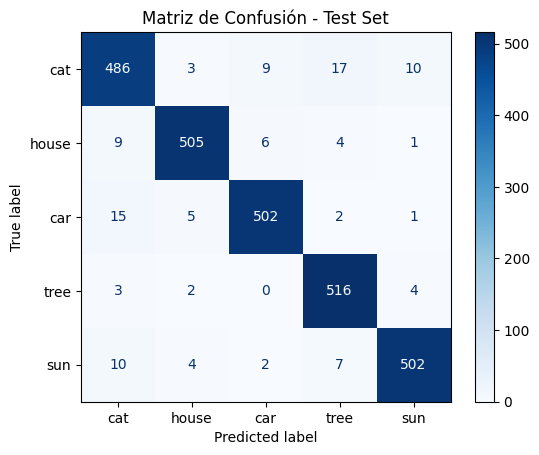

              precision    recall  f1-score   support

         cat       0.93      0.93      0.93       525
       house       0.97      0.96      0.97       525
         car       0.97      0.96      0.96       525
        tree       0.95      0.98      0.96       525
         sun       0.97      0.96      0.96       525

    accuracy                           0.96      2625
   macro avg       0.96      0.96      0.96      2625
weighted avg       0.96      0.96      0.96      2625



In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Evaluación final sobre test (datos que el modelo nunca vio)
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nAccuracy en test: {test_acc:.4f}")

# Matriz de confusión
y_pred = model.predict(X_test).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categorias)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Test Set')
plt.show()

# Reporte con precision/recall/f1 por categoría (útil también para el informe)
print(classification_report(y_test, y_pred, target_names=categorias))

In [13]:
model.save('modelo_adivina_mi_dibujo.h5')

from google.colab import files
files.download('modelo_adivina_mi_dibujo.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>